# Ecuación de calor en una y dos dimensiones

Este programa busca simular la ecuación de calor,

$\begin{equation}
\frac{\partial \Psi}{\partial t} = \alpha \nabla^2 \Psi
\end{equation}
$
en una y dos dimensiones espaciales.

# Ecuacion de calor 1D

$\begin{equation}
\frac{\partial \Psi}{\partial t} = \alpha \frac{\partial^2 \Psi}{\partial x^2}
\end{equation}$

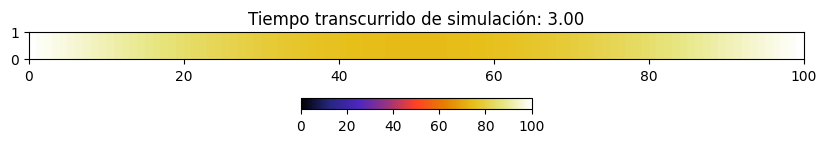

El tiempo que tardo la simulación en correr es: 160.51 segundos
La temperatura de cada nodo es: [100.    99.18  98.35  97.53  96.71  95.9   95.08  94.28  93.48  92.68
  91.89  91.11  90.34  89.58  88.83  88.1   87.37  86.66  85.95  85.27
  84.6   83.94  83.3   82.68  82.07  81.49  80.92  80.37  79.84  79.33
  78.84  78.37  77.92  77.5   77.1   76.72  76.37  76.04  75.73  75.45
  75.19  74.96  74.75  74.57  74.42  74.29  74.18  74.1   74.05  74.02
  74.02  74.05  74.1   74.18  74.29  74.42  74.57  74.75  74.96  75.19
  75.45  75.73  76.04  76.37  76.72  77.1   77.5   77.92  78.37  78.84
  79.33  79.84  80.37  80.92  81.49  82.07  82.68  83.3   83.94  84.6
  85.27  85.95  86.66  87.37  88.1   88.83  89.58  90.34  91.11  91.89
  92.68  93.48  94.28  95.08  95.9   96.71  97.53  98.35  99.18 100.  ]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

# Ecuación del calor en 1D. Sobre una barra de largo L

# Declaramos los parametros
alpha = 113 # mm^2 / s
L = 50 # mm
nodos = 100
t = 3
T_0 = 20

# Diferenciales
dx = L / nodos
dt = 0.5 * dx**2 / alpha
t_nodos = int(t / dt)

# Temperatura inicial de los nodos
T = np.zeros(nodos) + T_0

# Condiciones de borde
T[0] = 100
T[-1] = 100

# Grafico
fig, axis = plt.subplots(figsize=(10,1))
mesh = axis.pcolormesh([T], cmap=plt.cm.CMRmap, vmin=0, vmax=100)
plt.colorbar(mesh, ax=axis, orientation= "horizontal", pad=0.5)

# Tiempo inicial real
start_time = time.time()

# Simulación
contador = 0

while contador < t:
    w = T.copy()
    for i in range(1, nodos-1):
        T[i] = alpha * ((w[i-1] - 2*w[i] + w[i+1]) / dx**2) * dt + w[i]

    contador += dt

    # Actualización del grafico 
    mesh.set_array(T)
    axis.set_title(f"Tiempo transcurrido de simulación: {contador:.2f}")
    clear_output(wait=True)
    display(fig)

# Temperatura final de cada nodo
T_por_nodo = np.round(T,decimals=2)

# Cerrar el grafico final
plt.close()

# Tiempo real total y temperatura de cada nodo
end_time = time.time()
print(f"El tiempo que tardo la simulación en correr es: {end_time - start_time:.2f} segundos")
print(f"La temperatura de cada nodo es: {T_por_nodo}")

# Ecuación de calor 2D

$\begin{equation}
\frac{\partial \Psi}{\partial t} = \alpha \left( \frac{\partial^2 \Psi}{\partial x^2} + \frac{\partial^2 \Psi}{\partial y^2} \right)
\end{equation}$

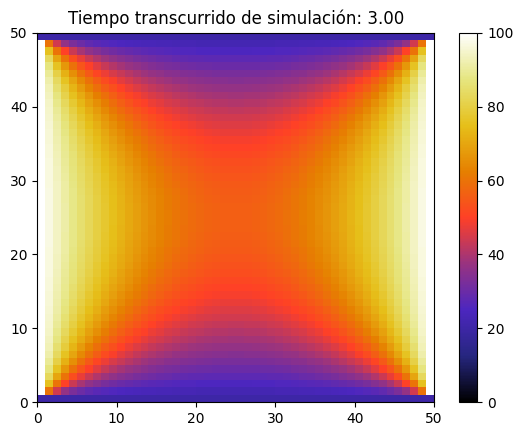

El tiempo que tardo la simulación en correr es: 95.83 segundos
La temperatura de cada nodo es: [[ 20.    20.    20.   ...  20.    20.    20.  ]
 [100.    59.98  44.16 ...  44.16  59.98 100.  ]
 [100.    75.78  59.93 ...  59.93  75.78 100.  ]
 ...
 [100.    75.78  59.93 ...  59.93  75.78 100.  ]
 [100.    59.98  44.16 ...  44.16  59.98 100.  ]
 [ 20.    20.    20.   ...  20.    20.    20.  ]]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display

# Ecuación del calor en 2D. Sobre una superficie 

# Declaramos los parametros
alpha = 113 # mm^2 / s
L = 50 # mm
nodos = 50
t = 3
T_0 = 20

# Diferenciales
dx = L / nodos
dy = L / nodos
dt = min(dx**2 / (4 * alpha), dy**2 / (4 * alpha))
t_nodos = int(t / dt)

# Temperatura inicial de los nodos
T = np.zeros((nodos, nodos)) + T_0

# Condiciones de borde
T[:,0] = 100
T[:,-1] = 100
T[0,:] = 20
T[-1,:] = 20

# Grafico
fig, axis = plt.subplots()
mesh = axis.pcolormesh(T, cmap=plt.cm.CMRmap, vmin=0, vmax=100)
plt.colorbar(mesh, ax=axis)

# Tiempo inicial real
start_time = time.time()

# Simulación
contador = 0

while contador < t:
    w = T.copy()
    for i in range(1, nodos-1):
        for j in range(1, nodos-1):
            ddTx = (w[i-1,j] - 2*w[i,j] + w[i+1,j]) / dx**2
            ddTy = (w[i,j-1] - 2*w[i,j] + w[i,j+1]) / dy**2
            T[i,j] = alpha * (ddTx + ddTy) * dt + w[i,j]

    contador += dt

    # Actualización del grafico 
    mesh.set_array(T.ravel())
    axis.set_title(f"Tiempo transcurrido de simulación: {contador:.2f}")
    clear_output(wait=True)
    display(fig)

# Temperatura final de cada nodo
T_por_nodo = np.round(T,decimals=2)

# Cerrar el grafico final
plt.close()

# Tiempo real total y temperatura de cada nodo
end_time = time.time()
print(f"El tiempo que tardo la simulación en correr es: {end_time - start_time:.2f} segundos")
print(f"La temperatura de cada nodo es: {T_por_nodo}")